---
title: "Taller - Sesion 5 - Series de Tiempo y Python IIE - UNAM"
author:
  - name: Luis E. Ascencio G. 
    orcid: 0009-0009-1694-5993
    email: luis.ascencio@cimat.mx
    affiliation: 
      - name: CIMAT
        city: Guanajuato
        state: Guanajuato
        url: https://www.cimat.mx
abstract: > 
  Este Notebook incluye una introduccion al manejo de Series de Tiempo con Python 
keywords:
  - Series de Tiempo
  - ARIMA
  - Python
  - R
  - Estadistica
license: "CC BY"
copyright: 
  holder: Luis E. Ascencio G.
  year: 2025
citation: 
  container-title: CIMAT
  volume: 1
  issue: 1
  doi: 000000/00000000
funding: "This work was supported by the Mexican Secretariat of Science, Humanities, Technology, and Innovation (SECIHTI, México) project CBF2023-2024-3976. Luis Enrique Ascencio Gorozpe is a doctoral student from the PhD in Probability and Statistics program, at Mathematics research center (CIMAT), he received  fellowship with number (CVU) 695305 from SECIHTI."
format:
  pdf:
    documentclass: scrartcl
    toc: true
    number-sections: true
    colorlinks: true
---

In [1]:
import numpy as np
import pandas as pd
from pandas import read_excel # funcion para leer archivos de excel
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt

# statsmodels
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


import pmdarima as pm
from pmdarima import ARIMA
from pmdarima import auto_arima

import sktime
from sktime import datasets
from sktime.utils import plot_series

import warnings
warnings.filterwarnings("ignore")


In [2]:
#!pip install xlrd
#!pip install sktime
#!pip install seaborn

In [22]:
h=30

In [15]:
df = pd.read_csv('AirPassengers.csv')
df1 = read_excel('ClayBricks.xls')
df2 = read_excel('Electricity.xls')
df3 = read_excel('MilkProduction.xls')
df4 = read_excel('JapaneseCars.xls')
df5 = read_excel('HouseSales.xls')

In [23]:
dates=pd.to_datetime(df["Month"])
ts=pd.Series(np.array(df["#Passengers"]),index=dates)

In [24]:
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Length: 144, dtype: int64

In [25]:
from pmdarima.datasets import load_wineind

# this is a dataset from R
wineind = load_wineind().astype(np.float64)

In [26]:
len(wineind)

176

In [27]:
stepwise_fit = pm.auto_arima(wineind, start_p=1, start_q=1,
                              max_p=3, max_q=3, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=3066.492, Time=0.45 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3131.408, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3097.884, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3066.329, Time=0.13 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3089.456, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3067.457, Time=0.22 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=3067.481, Time=0.61 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3071.631, Time=0.13 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=3.14 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=3117.921, Time=0.25 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=3065.533, Time=0.21 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=3087.883, Time=0.07 sec
 ARIMA(0,1,2)(1,1,1)[12]             : AIC=3066.239, Time=0.44 sec
 ARIMA(0,1,2)(0,1,2)[12]             : AIC=3066.373, Time=0.78 sec
 ARIMA(0,1,2)(1,1,0)[12]

In [10]:
df_fit = pm.auto_arima(ts, start_p=1, start_q=1,
                              max_p=3, max_q=3, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.29 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.19 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=1.13 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.89 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.33 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.47 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.63 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=1.02 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.55 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.13 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=3.10 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [28]:
df_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Mon, 03 Nov 2025   AIC                           1019.178
Time:                                     11:50:22   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
ts_pre=df_fit.predict(h)

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

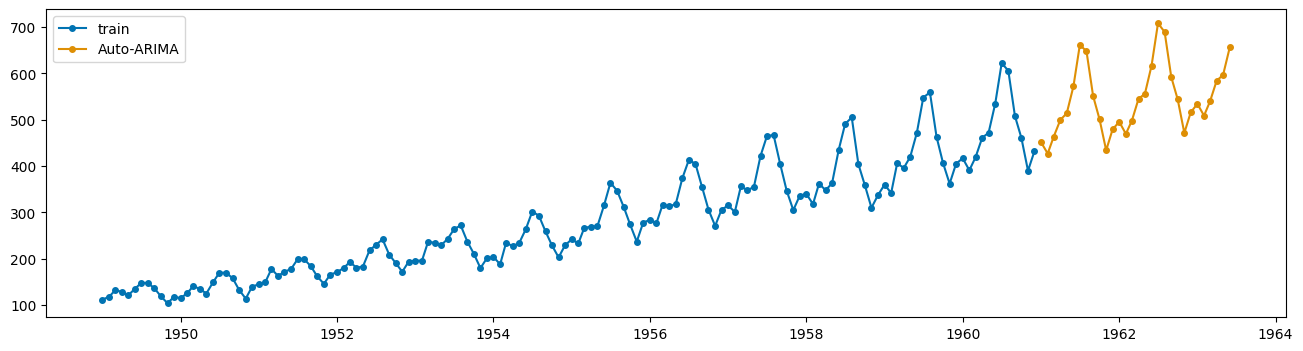

In [30]:
plot_series(ts,ts_pre,labels=["train","Auto-ARIMA"])

In [32]:
dates1=pd.to_datetime(df1["Dates"])
ts1=pd.Series(np.array(df1["Bricks"]),index=dates1)

In [33]:
ts1

Dates
1956-03-01    189
1956-04-01    204
1956-05-01    208
1956-06-01    197
1956-07-01    187
             ... 
1968-09-01    476
1968-10-01    443
1968-11-01    421
1968-12-01    472
1969-01-01    494
Length: 155, dtype: int64

In [34]:
df1_fit = pm.auto_arima(ts1, start_p=1, start_q=1,
                              max_p=4, max_q=4, m=12, start_P=0, 
                              seasonal=True,
                              d=1, D=1, trace=True,
                              error_action='ignore',  # don't want to know if an order does not work
                              suppress_warnings=True,  # don't want convergence warnings
                              stepwise=True)  # set to stepwise

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1323.673, Time=0.75 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1366.878, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1336.158, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1320.197, Time=0.24 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1365.182, Time=0.05 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1321.846, Time=0.54 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1321.857, Time=1.17 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1337.557, Time=0.12 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=3.83 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1320.760, Time=0.14 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=1321.569, Time=0.38 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1319.848, Time=0.20 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1364.159, Time=0.02 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1321.518, Time=0.29 sec
 ARIMA(1,1,0)(0,1,2)[12]

In [35]:
ts1_pre=df1_fit.predict(h)

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

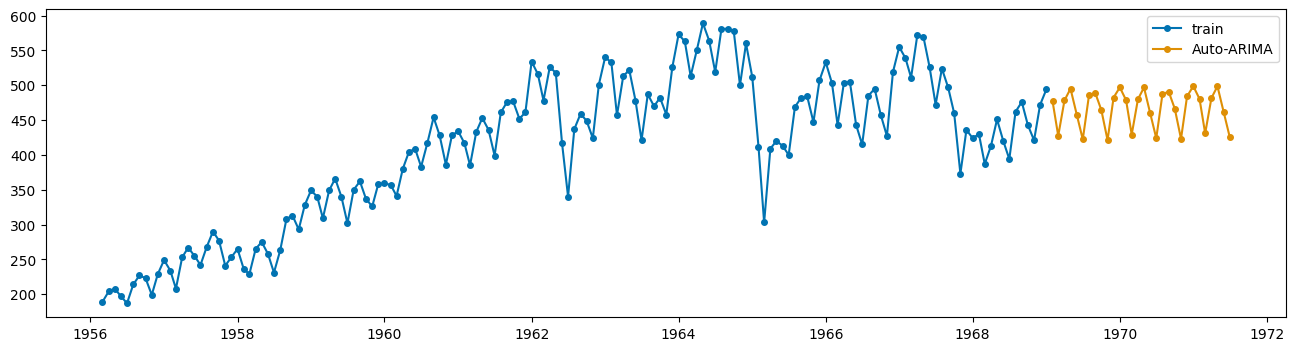

In [36]:
plot_series(ts1,ts1_pre,labels=["train","Auto-ARIMA"])